# Huấn luyện mô hình — VSL v2 Bảng chữ cái

**Dataset:** VSL v2 — 25 class, 58.439 ảnh skeleton 224×224  
**Mô hình:** MobileNetV2 (pretrained) + Custom CNN (so sánh)  
**GPU:** T4 khuyến nghị (~10–15 phút/model)

### Mục lục
1. Setup & Cấu hình
2. Dataset & DataLoader
3. Định nghĩa mô hình
4. Huấn luyện
5. Đánh giá chi tiết
6. Confusion Matrix & Per-class Analysis
7. Lưu mô hình & Export

## 1. Setup & Cấu hình

In [1]:
import os, json, time, copy, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from torchvision.models import MobileNet_V2_Weights
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, top_k_accuracy_score
)

# ── Reproducibility ───────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# ── Device ────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [2]:
# ── Cấu hình toàn cục ─────────────────────────────────────────────────────
# Đường dẫn — chỉnh cho phù hợp môi trường
ROOT      = Path('/kaggle/input/datasets/cuongnk9104/vsl-v2/v2')
OUT_DIR   = Path('/kaggle/working')
OUT_DIR.mkdir(exist_ok=True)

# Hyperparameters
IMG_SIZE    = 224          # Khớp chính xác với dataset (không cần resize)
BATCH_SIZE  = 64           # T4: 64 | CPU: 16
NUM_WORKERS = 2
PIN_MEMORY  = DEVICE.type == 'cuda'

# Training
EPOCHS_FROZEN  = 5         # Giai đoạn 1: chỉ train head, backbone frozen
EPOCHS_FINETUNE= 20        # Giai đoạn 2: unfreeze, fine-tune toàn bộ
LR_HEAD        = 1e-3      # LR giai đoạn 1
LR_FINETUNE    = 1e-4      # LR giai đoạn 2
LR_BACKBONE    = 1e-5      # LR riêng cho backbone (thấp hơn head)
WEIGHT_DECAY   = 1e-4
PATIENCE       = 7         # EarlyStopping

# Split ratio
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
# TEST_RATIO  = 0.15 (phần còn lại)

print('Cấu hình:')
print(f'  ROOT      : {ROOT}')
print(f'  IMG_SIZE  : {IMG_SIZE}')
print(f'  BATCH     : {BATCH_SIZE}')
print(f'  Epochs    : {EPOCHS_FROZEN} (frozen) + {EPOCHS_FINETUNE} (finetune)')

Cấu hình:
  ROOT      : /kaggle/input/datasets/cuongnk9104/vsl-v2/v2
  IMG_SIZE  : 224
  BATCH     : 64
  Epochs    : 5 (frozen) + 20 (finetune)


## 2. Dataset & DataLoader

In [3]:
# ── Quét dataset & tạo label map ──────────────────────────────────────────
IMG_EXTS = {'.jpg', '.jpeg', '.png'}

records = []
for cls_dir in sorted(ROOT.iterdir()):
    if not cls_dir.is_dir(): continue
    for img_path in cls_dir.iterdir():
        if img_path.suffix.lower() in IMG_EXTS:
            records.append({'path': str(img_path), 'class': cls_dir.name})

df = pd.DataFrame(records)

# Label encoding
classes    = sorted(df['class'].unique())
NUM_CLASSES= len(classes)
cls2idx    = {c: i for i, c in enumerate(classes)}
idx2cls    = {i: c for c, i in cls2idx.items()}
df['label']= df['class'].map(cls2idx)

# Lưu label map
with open(OUT_DIR / 'label_map.json', 'w', encoding='utf-8') as f:
    json.dump(cls2idx, f, ensure_ascii=False, indent=2)

print(f'Số class    : {NUM_CLASSES}')
print(f'Tổng ảnh    : {len(df):,}')
print(f'Classes     : {classes}')

Số class    : 25
Tổng ảnh    : 58,439
Classes     : ['A', 'B', 'C', 'D', 'E', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'Râu', 'S', 'T', 'U', 'V', 'X', 'Y', 'mũ', 'Đ']


In [4]:
# ── Stratified split ──────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df, test_size=(1 - TRAIN_RATIO),
    stratify=df['label'], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5,
    stratify=temp_df['label'], random_state=SEED
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train : {len(train_df):,} ({len(train_df)/len(df)*100:.1f}%)')
print(f'Val   : {len(val_df):,} ({len(val_df)/len(df)*100:.1f}%)')
print(f'Test  : {len(test_df):,} ({len(test_df)/len(df)*100:.1f}%)')

Train : 40,907 (70.0%)
Val   : 8,766 (15.0%)
Test  : 8,766 (15.0%)


In [5]:
# ── Transforms ────────────────────────────────────────────────────────────
# Lưu ý: ảnh là skeleton grayscale lưu dạng RGB → normalize theo mean/std
# đo thực tế từ EDA: brightness_mean=14/255≈0.055, std≈0.21
# Tuy nhiên dùng ImageNet mean/std vẫn ổn vì MobileNetV2 sẽ adapt qua BN

MEAN = [0.055, 0.055, 0.055]   # Từ EDA: brightness_mean/255
STD  = [0.210, 0.210, 0.210]   # Ước tính từ contrast_mean

train_transform = transforms.Compose([
    # Augmentation — nhẹ vì ảnh skeleton đã rất chuẩn
    transforms.RandomRotation(degrees=15),          # Xoay ±15°
    transforms.RandomHorizontalFlip(p=0.3),         # Lật ngang (cẩn thận: ảnh hưởng ý nghĩa)
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),   # Dịch chuyển nhỏ
        scale=(0.95, 1.05),       # Scale nhỏ
    ),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

print('Transforms đã định nghĩa.')
print(f'Train augmentation: Rotate±15°, HFlip(p=0.3), Affine')
print(f'Val/Test: ToTensor + Normalize only')

Transforms đã định nghĩa.
Train augmentation: Rotate±15°, HFlip(p=0.3), Affine
Val/Test: ToTensor + Normalize only


In [6]:
# ── Custom Dataset ────────────────────────────────────────────────────────
class VSLDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row['path']).convert('RGB')
        label = int(row['label'])
        if self.transform:
            img = self.transform(img)
        return img, label

# ── DataLoaders ───────────────────────────────────────────────────────────
train_ds = VSLDataset(train_df, train_transform)
val_ds   = VSLDataset(val_df,   val_transform)
test_ds  = VSLDataset(test_df,  val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')

# Kiểm tra 1 batch
imgs, labels = next(iter(train_loader))
print(f'\nBatch shape : {imgs.shape}  (B, C, H, W)')
print(f'Label range : {labels.min().item()} – {labels.max().item()}')
print(f'Pixel range : [{imgs.min():.3f}, {imgs.max():.3f}]')

Train batches : 640
Val   batches : 137
Test  batches : 137

Batch shape : torch.Size([64, 3, 224, 224])  (B, C, H, W)
Label range : 1 – 24
Pixel range : [-0.262, 4.500]


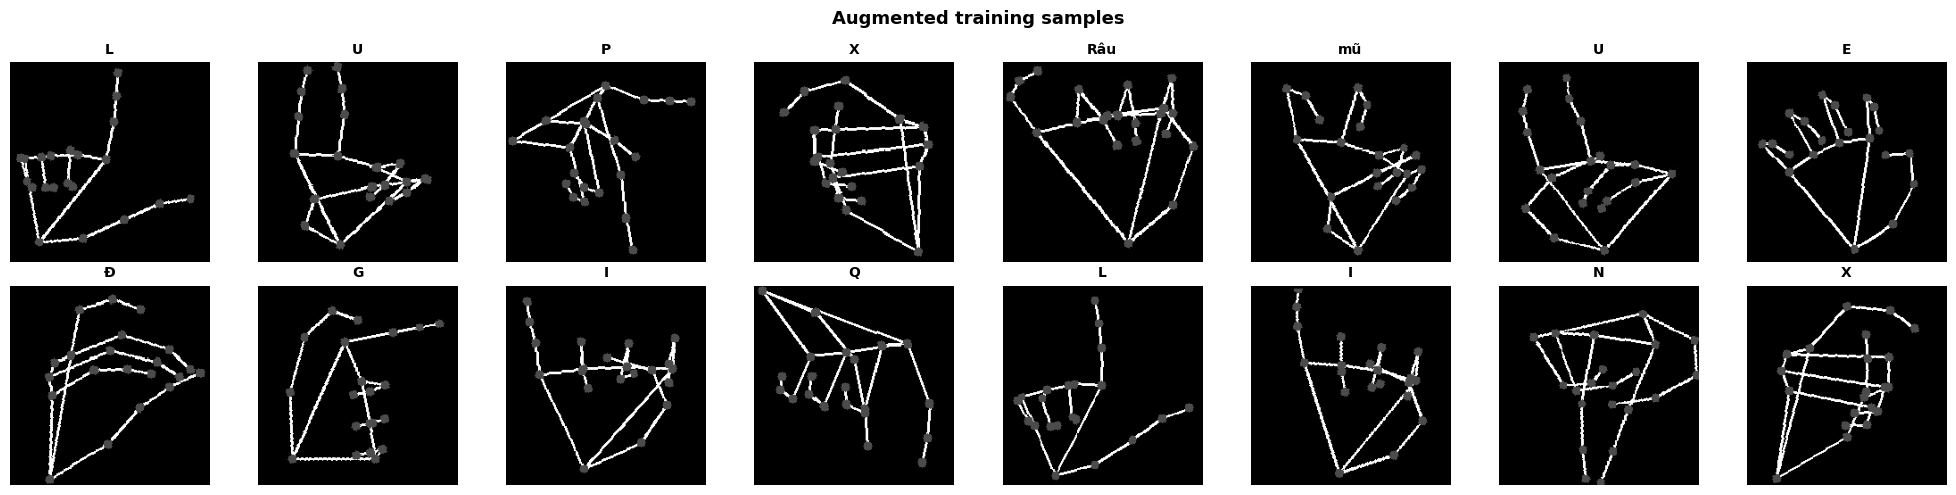

In [7]:
# ── Visualize augmented samples ───────────────────────────────────────────
fig, axes = plt.subplots(2, 8, figsize=(20, 5))
axes = axes.flatten()

for i, (img_t, label) in enumerate(zip(imgs[:16], labels[:16])):
    # Denormalize để hiển thị
    mean_t = torch.tensor(MEAN).view(3,1,1)
    std_t  = torch.tensor(STD).view(3,1,1)
    img_show = (img_t * std_t + mean_t).clamp(0,1)
    axes[i].imshow(img_show.permute(1,2,0).numpy())
    axes[i].set_title(idx2cls[label.item()], fontsize=10, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Augmented training samples', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Định nghĩa mô hình

In [8]:
# ── Model 1: MobileNetV2 Fine-tuning ──────────────────────────────────────
# Lý do chọn:
# - Pretrained ImageNet: low-level edge/line features vẫn hữu ích cho skeleton
# - 224×224 input khớp chính xác dataset, không cần resize
# - ~3.4M params: nhẹ, train nhanh, inference real-time
# - Depthwise separable conv: hiệu quả với ảnh skeleton có ít texture

def build_mobilenetv2(num_classes, dropout=0.3):
    model = models.mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)

    # Thay classifier head
    in_features = model.classifier[1].in_features  # 1280
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(p=dropout / 2),
        nn.Linear(512, num_classes)
    )
    return model

def freeze_backbone(model):
    """Đóng băng backbone, chỉ train head"""
    for param in model.features.parameters():
        param.requires_grad = False

def unfreeze_backbone(model):
    """Mở khóa toàn bộ để fine-tune"""
    for param in model.features.parameters():
        param.requires_grad = True

def count_params(model):
    total    = sum(p.numel() for p in model.parameters())
    trainable= sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

model_mbv2 = build_mobilenetv2(NUM_CLASSES).to(DEVICE)
freeze_backbone(model_mbv2)
total, trainable = count_params(model_mbv2)
print('MobileNetV2:')
print(f'  Tổng params     : {total:,}')
print(f'  Trainable (head): {trainable:,}')
print(f'  Classifier head : {model_mbv2.classifier}')

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 202MB/s]

MobileNetV2:
  Tổng params     : 2,892,569
  Trainable (head): 668,697
  Classifier head : Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1280, out_features=512, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.15, inplace=False)
  (4): Linear(in_features=512, out_features=25, bias=True)
)


In [9]:
# ── Model 2: Custom CNN ───────────────────────────────────────────────────
# Để so sánh với MobileNetV2
# 4 conv blocks + BN + pooling → FC

class CustomCNN(nn.Module):
    def __init__(self, num_classes, dropout=0.4):
        super().__init__()

        def conv_block(in_ch, out_ch, pool=True):
            layers = [
                nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            ]
            if pool: layers.append(nn.MaxPool2d(2))
            return nn.Sequential(*layers)

        # 224 → 112 → 56 → 28 → 14
        self.features = nn.Sequential(
            conv_block(3,   64,  pool=True),   # 224→112, 64ch
            conv_block(64,  128, pool=True),   # 112→56,  128ch
            conv_block(128, 256, pool=True),   # 56→28,   256ch
            conv_block(256, 512, pool=True),   # 28→14,   512ch
        )
        self.pool = nn.AdaptiveAvgPool2d(1)    # 14→1, 512ch
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)

model_cnn = CustomCNN(NUM_CLASSES).to(DEVICE)
total, trainable = count_params(model_cnn)
print('CustomCNN:')
print(f'  Tổng params: {total:,}')
print(f'  Trainable  : {trainable:,}')

# Kiểm tra forward pass
with torch.no_grad():
    dummy = torch.randn(2, 3, 224, 224).to(DEVICE)
    out_mbv2 = model_mbv2(dummy)
    out_cnn  = model_cnn(dummy)
print(f'\nOutput shape MobileNetV2: {out_mbv2.shape}  → OK')
print(f'Output shape CustomCNN  : {out_cnn.shape}  → OK')

CustomCNN:
  Tổng params: 4,825,049
  Trainable  : 4,825,049

Output shape MobileNetV2: torch.Size([2, 25])  → OK
Output shape CustomCNN  : torch.Size([2, 25])  → OK


## 4. Huấn luyện

In [10]:
# ── Training utilities ────────────────────────────────────────────────────
class EarlyStopping:
    def __init__(self, patience=7, min_delta=1e-4, mode='max'):
        self.patience   = patience
        self.min_delta  = min_delta
        self.mode       = mode
        self.best       = None
        self.counter    = 0
        self.best_state = None

    def step(self, value, model):
        improved = (
            self.best is None or
            (self.mode == 'max' and value > self.best + self.min_delta) or
            (self.mode == 'min' and value < self.best - self.min_delta)
        )
        if improved:
            self.best       = value
            self.counter    = 0
            self.best_state = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
        return self.counter >= self.patience  # True = stop


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs      = model(imgs)
        loss         = criterion(outputs, labels)
        probs        = torch.softmax(outputs, dim=1)
        preds        = outputs.argmax(1)
        total_loss  += loss.item() * imgs.size(0)
        correct     += (preds == labels).sum().item()
        total       += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    return (
        total_loss / total,
        correct / total,
        np.array(all_preds),
        np.array(all_labels),
        np.array(all_probs)
    )


def train_model(model, model_name, train_loader, val_loader,
                epochs_frozen, epochs_finetune, device):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    history   = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'lr':[]}
    es        = EarlyStopping(patience=PATIENCE)
    t_start   = time.time()

    # ── Giai đoạn 1: Frozen backbone, train head ──────────────────────────
    is_mobilenet = isinstance(model, models.MobileNetV2)
    if is_mobilenet:
        freeze_backbone(model)
    init_lr   = LR_HEAD if is_mobilenet else LR_FINETUNE
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                            lr=init_lr, weight_decay=WEIGHT_DECAY)
    t_max_p1  = epochs_frozen if epochs_frozen > 0 else 1
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=t_max_p1)

    total_epochs = epochs_frozen + epochs_finetune
    print(f'\n{'='*60}')
    print(f'Training: {model_name}')
    print(f'  Phase 1 (frozen)  : {epochs_frozen} epochs, lr={LR_HEAD}')
    print(f'  Phase 2 (finetune): {epochs_finetune} epochs, lr={LR_FINETUNE}')
    print(f'{'='*60}')

    for epoch in range(1, total_epochs + 1):
        # Chuyển sang giai đoạn fine-tune
        if epoch == epochs_frozen + 1:
            if is_mobilenet:
                unfreeze_backbone(model)
            # Differential LR: backbone thấp hơn head
            if is_mobilenet:
                param_groups = [
                    {'params': model.features.parameters(),  'lr': LR_BACKBONE},
                    {'params': model.classifier.parameters(),'lr': LR_FINETUNE},
                ]
            else:
                param_groups = [{'params': model.parameters(), 'lr': LR_FINETUNE}]
            optimizer = optim.Adam(param_groups, weight_decay=WEIGHT_DECAY)
            scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs_finetune)
            es        = EarlyStopping(patience=PATIENCE)  # Reset ES cho phase 2
            if is_mobilenet:
                print(f'\n→ Phase 2 [MobileNetV2]: Unfreeze backbone, lr_backbone={LR_BACKBONE}, lr_head={LR_FINETUNE}')
            else:
                print(f'\n→ Phase 2 [CustomCNN]: Train toàn bộ, lr={LR_FINETUNE}')

        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        v_loss, v_acc, _, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        cur_lr = optimizer.param_groups[-1]['lr']
        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)
        history['lr'].append(cur_lr)

        phase = 'P1' if epoch <= epochs_frozen else 'P2'
        print(f'[{phase}] Epoch {epoch:3d}/{total_epochs} | '
              f'Loss: {t_loss:.4f}/{v_loss:.4f} | '
              f'Acc: {t_acc*100:.2f}%/{v_acc*100:.2f}% | '
              f'LR: {cur_lr:.2e}')

        # EarlyStopping chỉ áp dụng trong phase 2
        if epoch > epochs_frozen:
            if es.step(v_acc, model):
                print(f'\n⚡ Early stopping tại epoch {epoch} (best val_acc={es.best*100:.2f}%)')
                break

    # Restore best weights
    if es.best_state is not None:
        model.load_state_dict(es.best_state)

    elapsed = time.time() - t_start
    print(f'\n✅ Training xong! Thời gian: {elapsed/60:.1f} phút')
    print(f'   Best val_acc: {es.best*100:.2f}%' if es.best else '')

    return history

print('Training utilities sẵn sàng.')

Training utilities sẵn sàng.


In [11]:
# ── Train MobileNetV2 ─────────────────────────────────────────────────────
history_mbv2 = train_model(
    model_mbv2, 'MobileNetV2',
    train_loader, val_loader,
    EPOCHS_FROZEN, EPOCHS_FINETUNE,
    DEVICE
)


Training: MobileNetV2
  Phase 1 (frozen)  : 5 epochs, lr=0.001
  Phase 2 (finetune): 20 epochs, lr=0.0001
[P1] Epoch   1/25 | Loss: 1.0129/0.7838 | Acc: 90.00%/98.07% | LR: 9.05e-04
[P1] Epoch   2/25 | Loss: 0.8474/0.7429 | Acc: 95.64%/98.64% | LR: 6.55e-04
[P1] Epoch   3/25 | Loss: 0.8168/0.7280 | Acc: 96.42%/99.01% | LR: 3.45e-04
[P1] Epoch   4/25 | Loss: 0.7953/0.7102 | Acc: 97.15%/99.14% | LR: 9.55e-05
[P1] Epoch   5/25 | Loss: 0.7794/0.7036 | Acc: 97.48%/99.33% | LR: 0.00e+00

→ Phase 2 [MobileNetV2]: Unfreeze backbone, lr_backbone=1e-05, lr_head=0.0001
[P2] Epoch   6/25 | Loss: 0.7250/0.6620 | Acc: 98.95%/99.73% | LR: 9.94e-05
[P2] Epoch   7/25 | Loss: 0.6879/0.6511 | Acc: 99.66%/99.83% | LR: 9.76e-05
[P2] Epoch   8/25 | Loss: 0.6733/0.6452 | Acc: 99.82%/99.89% | LR: 9.46e-05
[P2] Epoch   9/25 | Loss: 0.6646/0.6393 | Acc: 99.87%/99.89% | LR: 9.05e-05
[P2] Epoch  10/25 | Loss: 0.6588/0.6356 | Acc: 99.90%/99.93% | LR: 8.54e-05
[P2] Epoch  11/25 | Loss: 0.6546/0.6329 | Acc: 99.92%/

In [12]:
# ── Train Custom CNN ──────────────────────────────────────────────────────
# Custom CNN không có frozen phase — train toàn bộ từ đầu
history_cnn = train_model(
    model_cnn, 'CustomCNN',
    train_loader, val_loader,
    epochs_frozen=0,             # Không có giai đoạn frozen
    epochs_finetune=EPOCHS_FROZEN + EPOCHS_FINETUNE,
    device=DEVICE
)


Training: CustomCNN
  Phase 1 (frozen)  : 0 epochs, lr=0.001
  Phase 2 (finetune): 25 epochs, lr=0.0001

→ Phase 2 [CustomCNN]: Train toàn bộ, lr=0.0001
[P2] Epoch   1/25 | Loss: 1.5944/0.9055 | Acc: 74.05%/95.30% | LR: 9.96e-05
[P2] Epoch   2/25 | Loss: 0.8440/0.7578 | Acc: 98.07%/98.84% | LR: 9.84e-05
[P2] Epoch   3/25 | Loss: 0.7571/0.7156 | Acc: 99.36%/99.65% | LR: 9.65e-05
[P2] Epoch   4/25 | Loss: 0.7232/0.7163 | Acc: 99.69%/99.71% | LR: 9.38e-05
[P2] Epoch   5/25 | Loss: 0.7062/0.6893 | Acc: 99.76%/99.71% | LR: 9.05e-05
[P2] Epoch   6/25 | Loss: 0.6948/0.6756 | Acc: 99.83%/99.83% | LR: 8.64e-05
[P2] Epoch   7/25 | Loss: 0.6860/0.6798 | Acc: 99.88%/99.82% | LR: 8.19e-05
[P2] Epoch   8/25 | Loss: 0.6794/0.6642 | Acc: 99.91%/99.75% | LR: 7.68e-05
[P2] Epoch   9/25 | Loss: 0.6753/0.6556 | Acc: 99.91%/99.92% | LR: 7.13e-05
[P2] Epoch  10/25 | Loss: 0.6711/0.6682 | Acc: 99.95%/99.92% | LR: 6.55e-05
[P2] Epoch  11/25 | Loss: 0.6683/0.6440 | Acc: 99.96%/99.90% | LR: 5.94e-05
[P2] Epoch

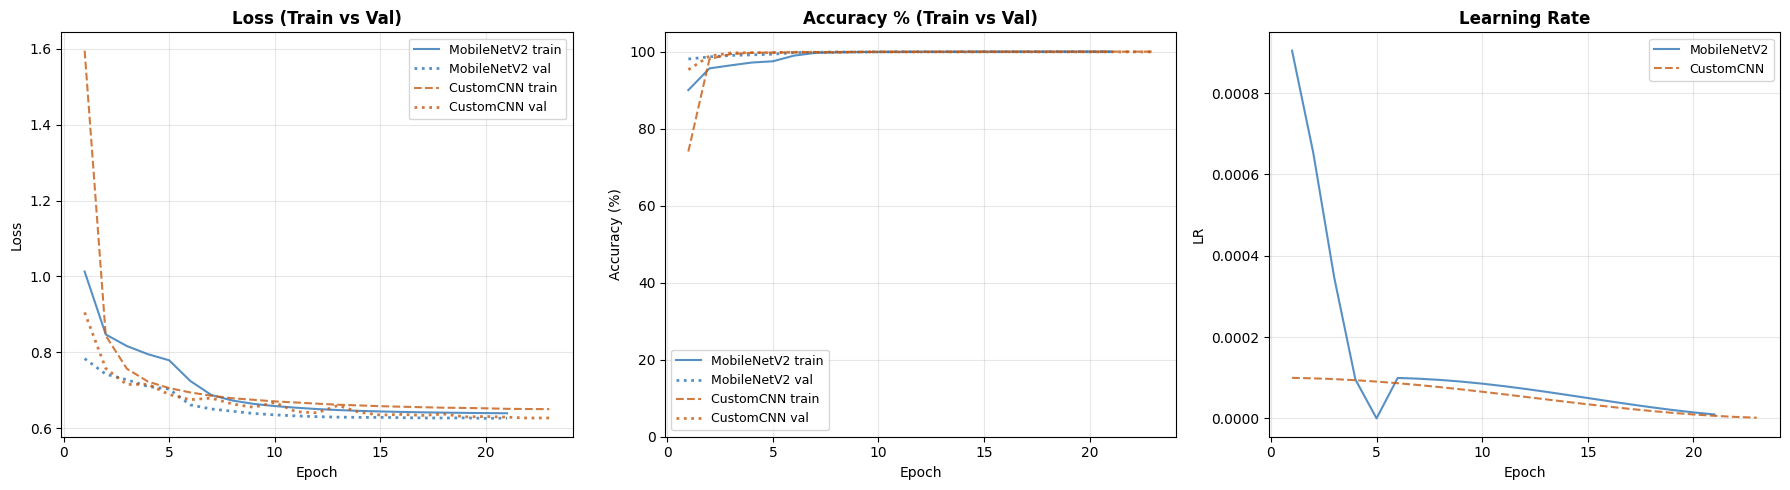

In [14]:
def plot_history(histories, labels, save_path=None):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    colors = ['#2E75B6', '#C55A11', '#1D7A45']
    styles = ['-', '--', '-.']

    for i, (h, label) in enumerate(zip(histories, labels)):
        epochs = range(1, len(h['train_loss']) + 1)
        c, s   = colors[i], styles[i]

        # ← Truyền color và linestyle riêng, không ghép chuỗi
        axes[0].plot(epochs, h['train_loss'], linestyle=s,  color=c, label=f'{label} train', alpha=0.8)
        axes[0].plot(epochs, h['val_loss'],   linestyle=':', color=c, label=f'{label} val',  alpha=0.8, linewidth=2)

        axes[1].plot(epochs, [a*100 for a in h['train_acc']], linestyle=s,  color=c, label=f'{label} train', alpha=0.8)
        axes[1].plot(epochs, [a*100 for a in h['val_acc']],   linestyle=':', color=c, label=f'{label} val',  alpha=0.8, linewidth=2)

        axes[2].plot(epochs, h['lr'], linestyle=s, color=c, label=label, alpha=0.8)

    for ax, title, ylabel in zip(axes,
        ['Loss (Train vs Val)', 'Accuracy % (Train vs Val)', 'Learning Rate'],
        ['Loss', 'Accuracy (%)', 'LR']):
        ax.set_title(title, fontweight='bold', fontsize=12)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    axes[1].set_ylim([0, 105])
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()

plot_history(
    [history_mbv2, history_cnn],
    ['MobileNetV2', 'CustomCNN'],
    save_path=OUT_DIR / 'training_curves.png'
)

## 5. Đánh giá chi tiết trên Test set

In [15]:
# ── Đánh giá trên test set ────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()

results = {}
for model, name in [(model_mbv2, 'MobileNetV2'), (model_cnn, 'CustomCNN')]:
    loss, acc, preds, labels_arr, probs = evaluate(model, test_loader, criterion, DEVICE)

    # Top-5 accuracy
    top5 = top_k_accuracy_score(labels_arr, probs, k=5) if NUM_CLASSES >= 5 else acc

    results[name] = {
        'loss': loss, 'top1': acc, 'top5': top5,
        'preds': preds, 'labels': labels_arr, 'probs': probs
    }
    print(f'\n{name}:')
    print(f'  Test Loss  : {loss:.4f}')
    print(f'  Top-1 Acc  : {acc*100:.2f}%')
    print(f'  Top-5 Acc  : {top5*100:.2f}%')


MobileNetV2:
  Test Loss  : 0.0868
  Top-1 Acc  : 99.98%
  Top-5 Acc  : 100.00%

CustomCNN:
  Test Loss  : 0.1118
  Top-1 Acc  : 99.99%
  Top-5 Acc  : 100.00%


In [16]:
# ── Bảng so sánh tổng hợp ─────────────────────────────────────────────────
print('\n' + '='*60)
print('SO SÁNH KẾT QUẢ')
print('='*60)

comp_df = pd.DataFrame({
    'Model'    : list(results.keys()),
    'Top-1 (%)': [f"{r['top1']*100:.2f}" for r in results.values()],
    'Top-5 (%)': [f"{r['top5']*100:.2f}" for r in results.values()],
    'Test Loss': [f"{r['loss']:.4f}"     for r in results.values()],
})
print(comp_df.to_string(index=False))

# Chọn model tốt nhất
best_name = max(results, key=lambda k: results[k]['top1'])
print(f'\n🏆 Model tốt nhất: {best_name} (Top-1: {results[best_name]["top1"]*100:.2f}%)')


SO SÁNH KẾT QUẢ
      Model Top-1 (%) Top-5 (%) Test Loss
MobileNetV2     99.98    100.00    0.0868
  CustomCNN     99.99    100.00    0.1118

🏆 Model tốt nhất: CustomCNN (Top-1: 99.99%)


## 6. Confusion Matrix & Per-class Analysis

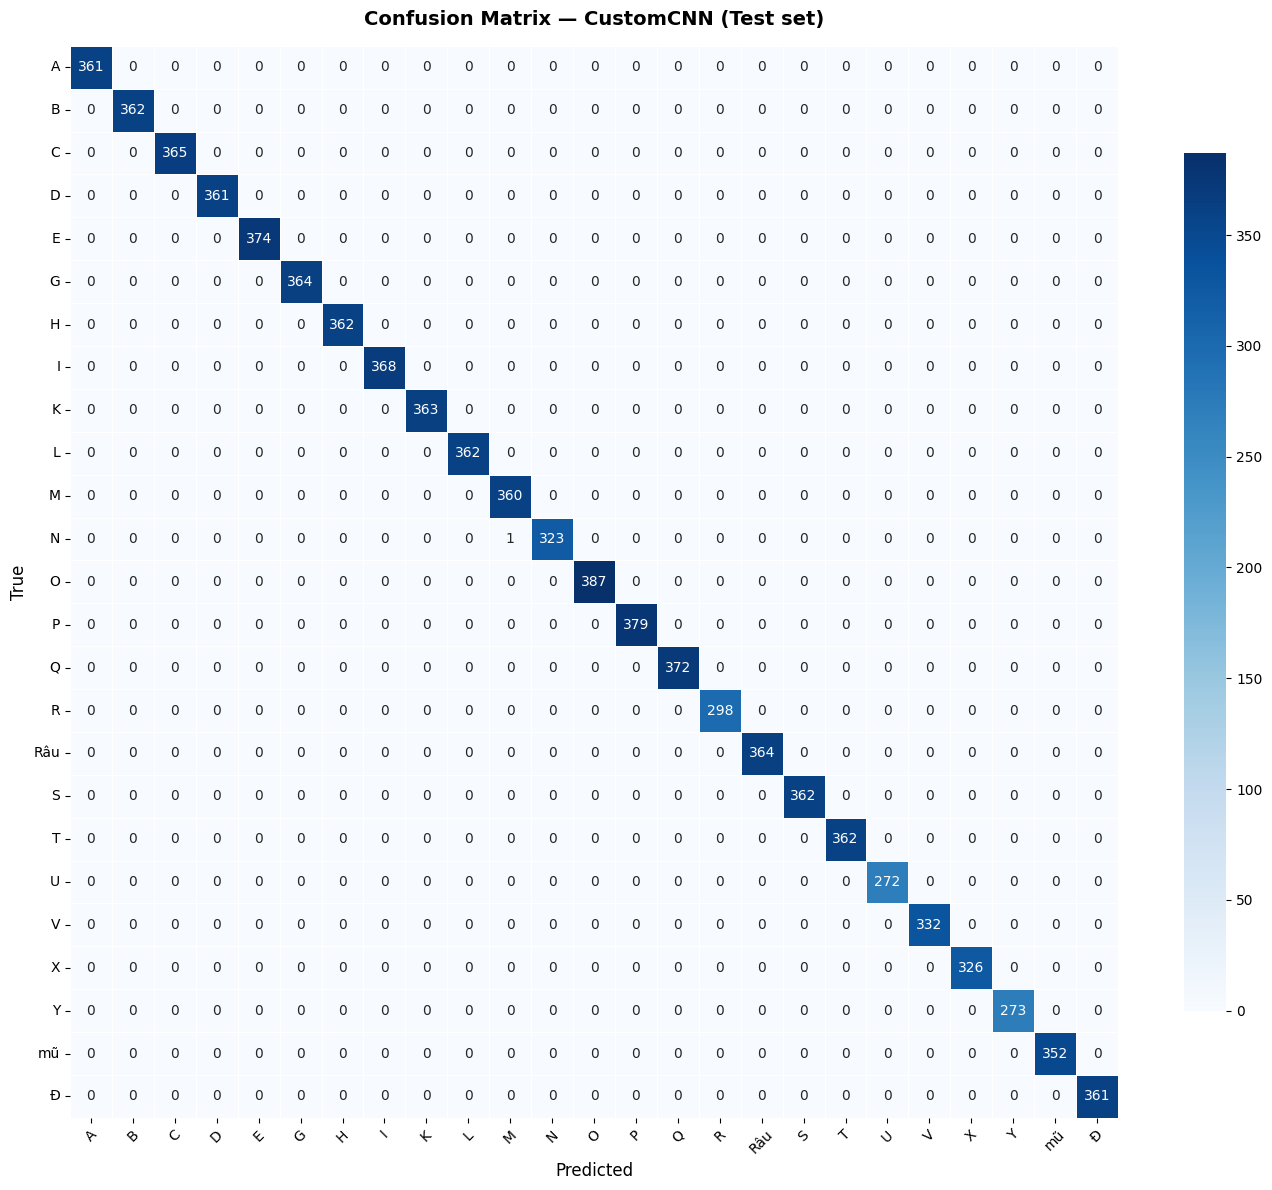

Saved: confusion_matrix.png


In [17]:
# ── Confusion Matrix cho model tốt nhất ──────────────────────────────────
best_result = results[best_name]
cm = confusion_matrix(best_result['labels'], best_result['preds'])

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=classes, yticklabels=classes,
    linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title(f'Confusion Matrix — {best_name} (Test set)', fontweight='bold', fontsize=14, pad=15)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(OUT_DIR / 'confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix.png')

In [18]:
# ── Per-class report ──────────────────────────────────────────────────────
report = classification_report(
    best_result['labels'], best_result['preds'],
    target_names=classes, output_dict=True
)
report_df = pd.DataFrame(report).T.iloc[:-3]  # Bỏ macro/weighted/accuracy rows
report_df  = report_df.drop(columns=['support'])
report_df  = report_df.astype(float).round(4)
report_df['accuracy_%'] = (report_df['recall'] * 100).round(2)

print('Per-class metrics:')
print(report_df.sort_values('recall').to_string())

# Class khó nhất và dễ nhất
worst  = report_df['recall'].idxmin()
best_c = report_df['recall'].idxmax()
print(f'\nClass dễ nhất  : {best_c} ({report_df.loc[best_c,"recall"]*100:.1f}%)')
print(f'Class khó nhất : {worst}  ({report_df.loc[worst,"recall"]*100:.1f}%)')

Per-class metrics:
     precision  recall  f1-score  accuracy_%
N       1.0000  0.9969    0.9985       99.69
A       1.0000  1.0000    1.0000      100.00
C       1.0000  1.0000    1.0000      100.00
B       1.0000  1.0000    1.0000      100.00
E       1.0000  1.0000    1.0000      100.00
G       1.0000  1.0000    1.0000      100.00
H       1.0000  1.0000    1.0000      100.00
D       1.0000  1.0000    1.0000      100.00
I       1.0000  1.0000    1.0000      100.00
K       1.0000  1.0000    1.0000      100.00
L       1.0000  1.0000    1.0000      100.00
M       0.9972  1.0000    0.9986      100.00
O       1.0000  1.0000    1.0000      100.00
P       1.0000  1.0000    1.0000      100.00
Q       1.0000  1.0000    1.0000      100.00
R       1.0000  1.0000    1.0000      100.00
Râu     1.0000  1.0000    1.0000      100.00
S       1.0000  1.0000    1.0000      100.00
T       1.0000  1.0000    1.0000      100.00
U       1.0000  1.0000    1.0000      100.00
V       1.0000  1.0000    1.0000    

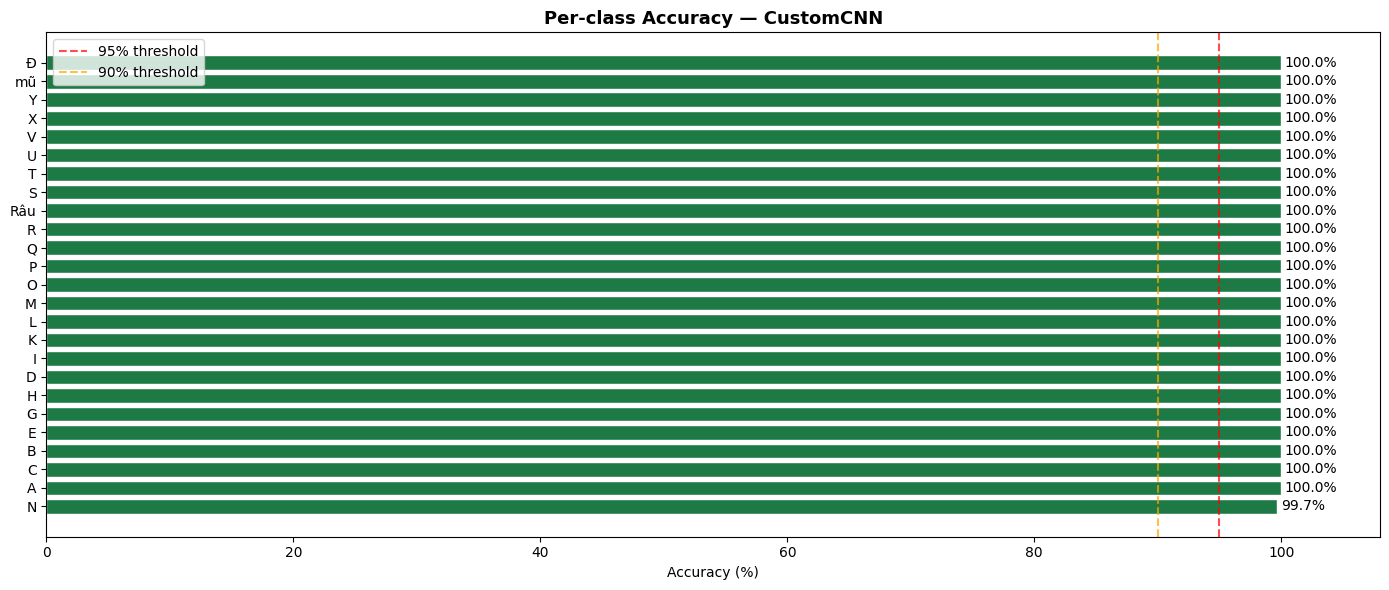

In [19]:
# ── Per-class accuracy bar chart ─────────────────────────────────────────
per_class_acc = report_df['recall'].sort_values()

fig, ax = plt.subplots(figsize=(14, 6))
colors  = ['#C00000' if v < 0.90 else '#C55A11' if v < 0.95 else '#1D7A45'
           for v in per_class_acc.values]
bars = ax.barh(per_class_acc.index, per_class_acc.values * 100, color=colors, edgecolor='white')
ax.axvline(95, color='red',    linestyle='--', alpha=0.7, label='95% threshold')
ax.axvline(90, color='orange', linestyle='--', alpha=0.7, label='90% threshold')

for bar, val in zip(bars, per_class_acc.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%', va='center', fontsize=10)

ax.set_title(f'Per-class Accuracy — {best_name}', fontweight='bold', fontsize=13)
ax.set_xlabel('Accuracy (%)')
ax.set_xlim([0, 108])
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'per_class_accuracy.png', dpi=120, bbox_inches='tight')
plt.show()

Tổng ảnh dự đoán sai: 1 / 8766 (0.0%)


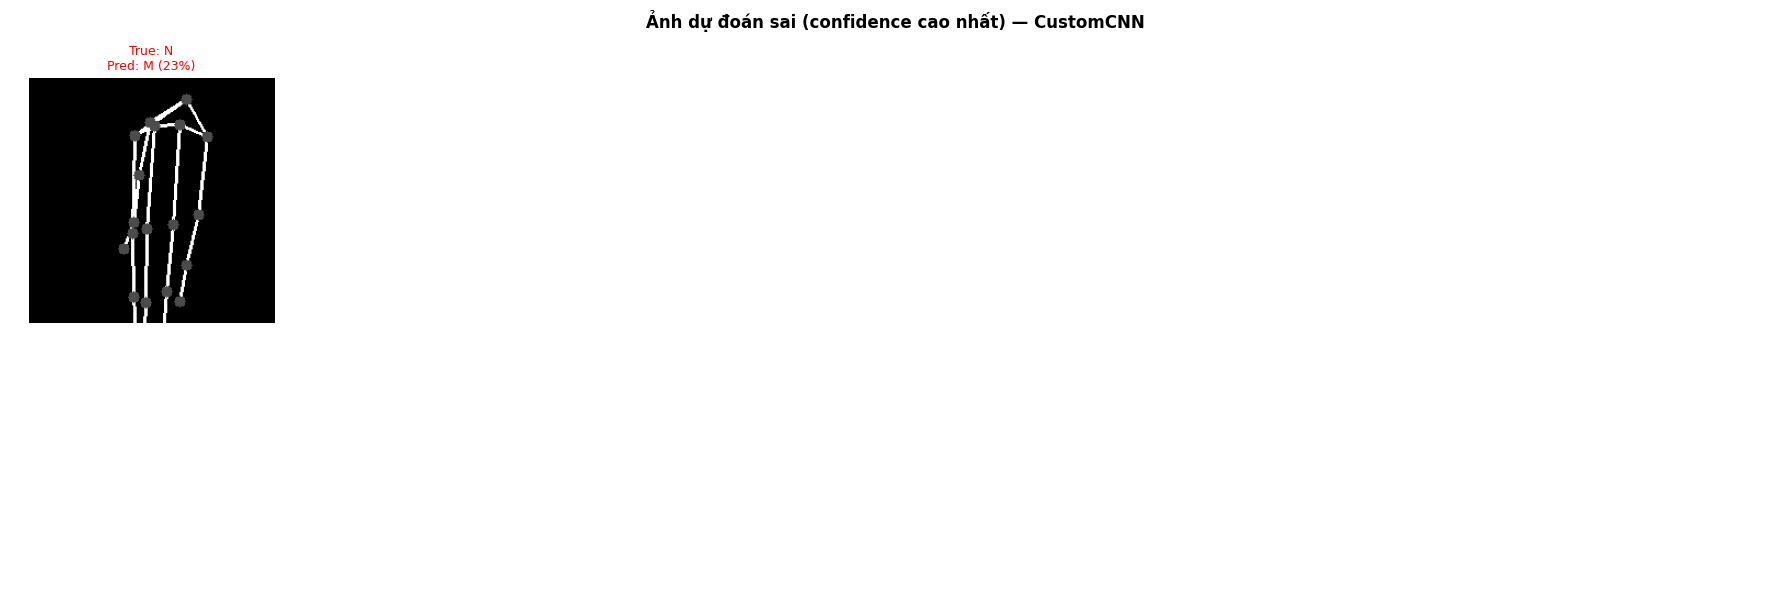

In [20]:
# ── Xem ảnh dự đoán sai ──────────────────────────────────────────────────
wrong_idx = np.where(best_result['preds'] != best_result['labels'])[0]
print(f'Tổng ảnh dự đoán sai: {len(wrong_idx)} / {len(best_result["labels"])} '
      f'({len(wrong_idx)/len(best_result["labels"])*100:.1f}%)')

# Hiển thị 12 ảnh sai đầu tiên (confidence cao nhất)
wrong_confs = [best_result['probs'][i, best_result['preds'][i]] for i in wrong_idx]
wrong_sorted = wrong_idx[np.argsort(wrong_confs)[::-1]][:12]

if len(wrong_sorted) > 0:
    n_show = min(12, len(wrong_sorted))
    fig, axes = plt.subplots(2, 6, figsize=(18, 6))
    axes = axes.flatten()

    for k, idx in enumerate(wrong_sorted[:n_show]):
        img_path = test_df.iloc[idx]['path']
        true_cls = idx2cls[best_result['labels'][idx]]
        pred_cls = idx2cls[best_result['preds'][idx]]
        conf     = best_result['probs'][idx, best_result['preds'][idx]]

        import cv2
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[k].imshow(img)
        axes[k].set_title(f'True: {true_cls}\nPred: {pred_cls} ({conf*100:.0f}%)',
                           fontsize=9,
                           color='red' if true_cls != pred_cls else 'green')
        axes[k].axis('off')

    for j in range(k + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f'Ảnh dự đoán sai (confidence cao nhất) — {best_name}',
                 fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'wrong_predictions.png', dpi=120, bbox_inches='tight')
    plt.show()

## 7. Lưu mô hình & Export

In [21]:
# ── Lưu weights ───────────────────────────────────────────────────────────
for model, name in [(model_mbv2, 'mobilenetv2'), (model_cnn, 'customcnn')]:
    # Full checkpoint (dùng để resume training)
    torch.save({
        'model_state_dict' : model.state_dict(),
        'num_classes'      : NUM_CLASSES,
        'classes'          : classes,
        'cls2idx'          : cls2idx,
        'img_size'         : IMG_SIZE,
        'mean'             : MEAN,
        'std'              : STD,
    }, OUT_DIR / f'{name}_checkpoint.pth')
    print(f'Saved: {name}_checkpoint.pth')

# Lưu history
with open(OUT_DIR / 'training_history.json', 'w') as f:
    json.dump({
        'MobileNetV2': {k: [float(v) for v in vals]
                        for k, vals in history_mbv2.items()},
        'CustomCNN':   {k: [float(v) for v in vals]
                        for k, vals in history_cnn.items()},
    }, f, indent=2)
print('Saved: training_history.json')

Saved: mobilenetv2_checkpoint.pth
Saved: customcnn_checkpoint.pth
Saved: training_history.json


In [25]:

!pip install onnx onnxscript -q
# ── Export ONNX (để deploy) ───────────────────────────────────────────────
best_model = model_mbv2 if best_name == 'MobileNetV2' else model_cnn
best_model.eval()

dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
onnx_path   = str(OUT_DIR / f'{best_name.lower()}_vsl_v2.onnx')

torch.onnx.export(
    best_model, dummy_input, onnx_path,
    export_params=True,
    opset_version=17,      # ← nâng lên 17, tránh downgrade
    dynamo=False,          # ← dùng exporter cũ, ổn định hơn
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch'}, 'output': {0: 'batch'}}
)

# Kiểm tra file thực sự có dữ liệu
size_mb = os.path.getsize(onnx_path) / 1e6
print(f'ONNX exported: {onnx_path}')
print(f'ONNX file size: {size_mb:.1f} MB')
assert size_mb > 1, "❌ File rỗng — export thất bại!"
print("✅ Export thành công")

/tmp/ipykernel_57/3145082845.py:9: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


ONNX exported: /kaggle/working/customcnn_vsl_v2.onnx
ONNX file size: 19.3 MB
✅ Export thành công


Ground truth: P


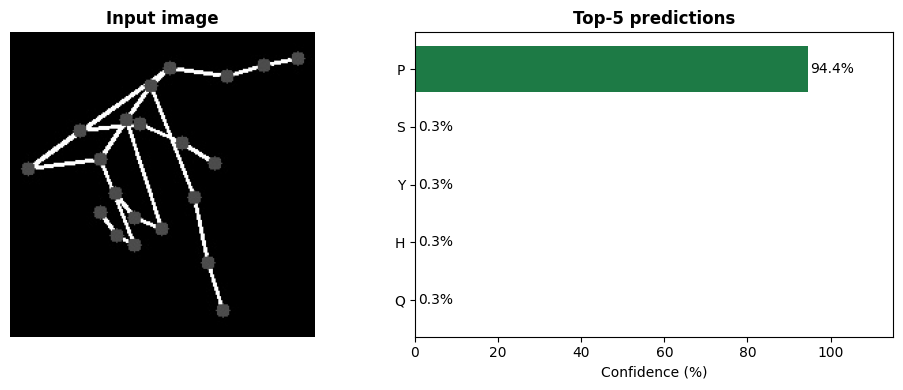

Predictions: [('P', 0.9444572329521179), ('S', 0.002883985871449113), ('Y', 0.002842230722308159), ('H', 0.002700946992263198), ('Q', 0.002552944701164961)]


In [26]:
# ── Inference demo — predict 1 ảnh ──────────────────────────────────────
def predict_image(image_path, model, transform, idx2cls, device, topk=3):
    """Predict 1 ảnh và trả về top-k kết quả"""
    img    = Image.open(image_path).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1)[0]

    top_probs, top_idx = probs.topk(topk)
    results = [(idx2cls[i.item()], p.item()) for i, p in zip(top_idx, top_probs)]

    # Hiển thị
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    import cv2
    img_cv = cv2.imread(str(image_path))
    axes[0].imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Input image', fontweight='bold')
    axes[0].axis('off')

    labels_bar = [r[0] for r in results]
    probs_bar  = [r[1]*100 for r in results]
    colors_bar = ['#1D7A45' if i==0 else '#2E75B6' for i in range(len(results))]
    axes[1].barh(labels_bar[::-1], probs_bar[::-1], color=colors_bar[::-1])
    axes[1].set_xlabel('Confidence (%)')
    axes[1].set_title(f'Top-{topk} predictions', fontweight='bold')
    for i, (l, p) in enumerate(zip(labels_bar[::-1], probs_bar[::-1])):
        axes[1].text(p + 0.5, i, f'{p:.1f}%', va='center')
    axes[1].set_xlim([0, 115])

    plt.tight_layout()
    plt.show()
    return results

# Demo với 1 ảnh ngẫu nhiên từ test set
sample_path = test_df.sample(1, random_state=0)['path'].values[0]
true_class  = test_df.sample(1, random_state=0)['class'].values[0]
print(f'Ground truth: {true_class}')
preds = predict_image(sample_path, model_mbv2, val_transform, idx2cls, DEVICE, topk=5)
print('Predictions:', preds)

In [27]:
# ── Tổng kết cuối ─────────────────────────────────────────────────────────
print('=' * 60)
print('TỔNG KẾT HUẤN LUYỆN')
print('=' * 60)
for name, r in results.items():
    print(f'{name}:')
    print(f'  Top-1 Accuracy: {r["top1"]*100:.2f}%')
    print(f'  Top-5 Accuracy: {r["top5"]*100:.2f}%')
    print(f'  Test Loss     : {r["loss"]:.4f}')
print()
print(f'Mô hình tốt nhất: {best_name}')
print()
print('Files đã lưu:')
for f in sorted(OUT_DIR.glob('*')):
    print(f'  {f.name}  ({f.stat().st_size/1e3:.0f} KB)')

TỔNG KẾT HUẤN LUYỆN
MobileNetV2:
  Top-1 Accuracy: 99.98%
  Top-5 Accuracy: 100.00%
  Test Loss     : 0.0868
CustomCNN:
  Top-1 Accuracy: 99.99%
  Top-5 Accuracy: 100.00%
  Test Loss     : 0.1118

Mô hình tốt nhất: CustomCNN

Files đã lưu:
  .virtual_documents  (4 KB)
  confusion_matrix.png  (105 KB)
  customcnn_checkpoint.pth  (19335 KB)
  customcnn_vsl_v2.onnx  (19298 KB)
  customcnn_vsl_v2.onnx.data  (19333 KB)
  label_map.json  (0 KB)
  mobilenetv2_checkpoint.pth  (11821 KB)
  per_class_accuracy.png  (84 KB)
  training_curves.png  (117 KB)
  training_history.json  (6 KB)
  wrong_predictions.png  (40 KB)
